In [1]:
""" ▶ SINGLE MEASUREMENT STERN-GERLACH EXPERIMENT ◀ """

' ▶ SINGLE MEASUREMENT STERN-GERLACH EXPERIMENT ◀ '

In [2]:
""" MEASRUE RIGHT AFTER PASSING TROUGH A AG OVEN """
import random
from numpy import pi
import numpy as np

a = random.random()
b = random.random()
norm = np.sqrt(a * np.conjugate(a) + b * np.conjugate(b))  # = a^2 + b^2

#NORMALIZATION
a = a / norm
b = b / norm
print(a, b)

0.2188741990495304 0.975753086077839


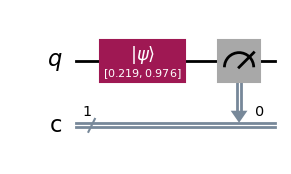

In [3]:
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, Parameter

# Define registers
qr = QuantumRegister(1, "q") # AG
cr = ClassicalRegister(1, "c") # SCREEN
qc = QuantumCircuit(qr, cr)

# Initialize the quantum state
qc.initialize([a, b])
qc.measure(0, 0)
qc.draw("mpl")

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
backend = service.least_busy()
print(backend.name)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_ibm = pm.run(qc)

num_shots = 1024

sampler = Sampler(mode = backend)
dist = sampler.run([qc_ibm], shots=num_shots).result()
counts = dist[0].data.c.get_counts()


qiskit_runtime_service.__init__:WARNING:2026-07-26 16:19:59,044: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: seolwon64. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-26 16:19:59,725: Using instance: seolwon64, plan: open


ibm_marrakesh


In [5]:
# FOR AerSimulator
# from qiskit_aer import AerSimulator

# This generates a simulator that mimics the real quantum system
# backend_sim = AerSimulator.from_backend(backend)

# Import an estimator, this time from qiskit (we import from Runtime for real hardware)
# from qiskit.primitives import BackendSamplerV2
# sampler = BackendSamplerV2(backend = backend_sim)

# num_shots = 1

# This runs the job
# dist = sampler.run([qc_ibm], shots = num_shots).result()

# This selects measurement counts for the 0th circuit, which in this case is the only circuit
# counts=dist[0].data.c.get_counts()

counts =  {'1': 974, '0': 50}


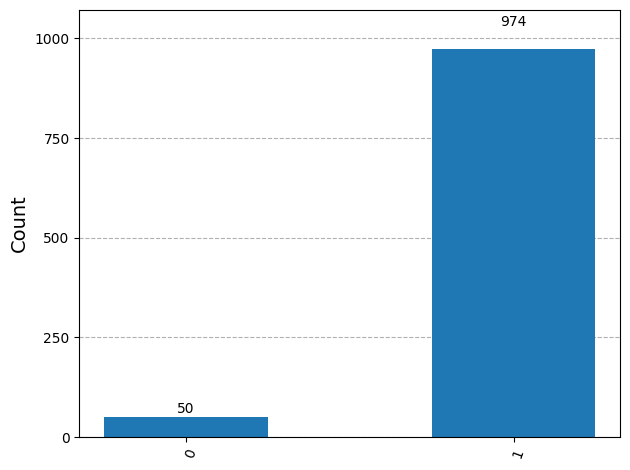

In [6]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

In [7]:
"""▶ RANDOM SPINS IN AN OVEN ◀"""

'▶ RANDOM SPINS IN AN OVEN ◀'

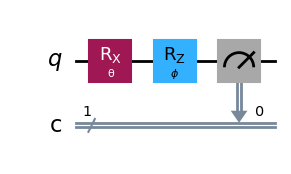

In [8]:
theta = Parameter("θ") # for rx
phi = Parameter("$\phi$") # for rz

# Define registers
qr = QuantumRegister(1, "q") 
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Add rotation gates for rotating the state of qubit 0 to random orientations
qc.rx(theta, 0)
qc.rz(phi, 0)
qc.measure(0, 0)

qc.draw("mpl")

In [9]:
# This uses a local simulator
from qiskit_aer import AerSimulator

# Import an estimator, this time from qiskit (we import from Runtime for real hardware)
from qiskit.primitives import BackendSamplerV2

backend_sim = AerSimulator.from_backend(backend)
sampler_sim = BackendSamplerV2(backend=backend_sim)

# from qiskit.primitives import BackendSamplerV2
# sampler = BackendSamplerV2(backend=backend)

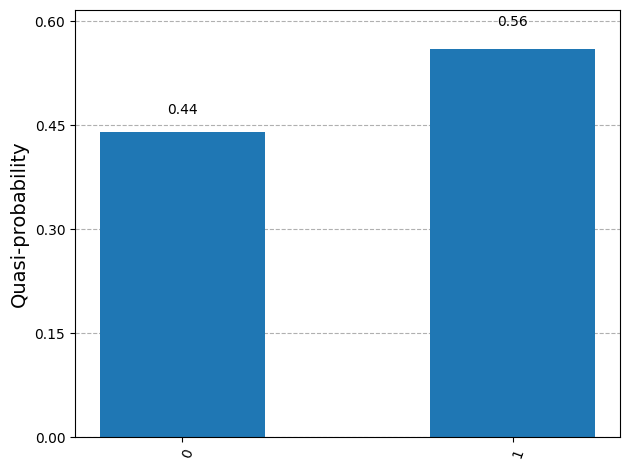

In [10]:
# A list to store the accumulated probabilities of the two possible measurement outcomes.
probslist = {"0": 0.0, "1": 0.0} # SCREEN SET = 0.0

# Choose how many "particles"/measurements
measurements = 100 # ATOMS = 100
num_shots = 1

for i in range(measurements):
    # Assign a random orientation for each measurement
    phi = random.random() * 2 * pi # RANGE = 0 - 2pi
    theta = random.random() * 2 * pi # RANGE = 0 - 2pi

    angles = [phi, theta]
    circuit = qc.assign_parameters(angles) 
    qc_ibm = pm.run(circuit)

    # Run the circuit
    # job = sampler.run([circuit],num_shots = 1)
    dist = sampler_sim.run([qc_ibm], shots=num_shots).result()

    # Update the list of probabilities
    zeroterm = dist[0].data.c.get_counts().get("0") or 0 # "or 0" means if the key doesn't exist, use 0
    oneterm = dist[0].data.c.get_counts().get("1") or 0
    probslist.update({"0": probslist.get("0") + zeroterm}) # if atom hits the upper screen, zeroterm = 1 → "0" = 1
    probslist.update({"1": probslist.get("1") + oneterm}) # if atom hits the lower screen, oneterm = 1 → "1" = 1

probslist.update({"0": probslist.get("0") / measurements}) # getting average
probslist.update({"1": probslist.get("1") / measurements})
# print(probslist)

plot_histogram(probslist)

In [11]:
"""▶ REPEATED MEASUREMENTS ◀"""

'▶ REPEATED MEASUREMENTS ◀'

In [12]:
from qiskit import QuantumCircuit

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)

# Initialize the qubit to be a mixture of 0 and 1 states.
qc.h(0)

# Add a first measurement
qc.measure(0, 0) #  COLLAPSED SUPERPOSITION WHEN IT MEASURED, NEXT QUBIT IS SAME.
qc.barrier()

# Add a second measurement
qc.measure(0, 1)

qc.draw("mpl")

qc_ibm = pm.run(qc)

{'00': 504, '11': 487, '01': 9}


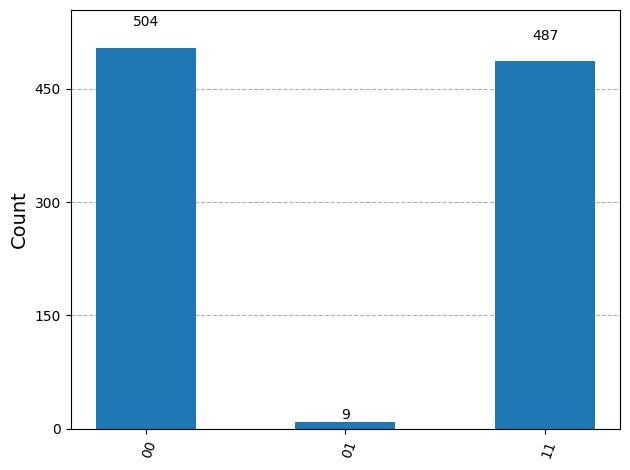

In [13]:
num_shots = 1000
dist = sampler.run([qc_ibm], shots=num_shots).result()
# To run on a simulator, uncomment the line below and comment out the line above.
# dist = sampler_sim.run([qc_ibm], shots=num_shots).result()
counts = dist[0].data.c.get_counts()
print(counts)

plot_histogram(counts)

In [14]:
# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Add a hadamard gate to rotate into the x-basis
qc.h(0)
qc.measure(0, 0)

qc.draw("mpl")

from qiskit.primitives import StatevectorSampler as Sampler

sampler_sv = Sampler()

job = sampler_sv.run([qc], shots=10000)
print(job.result()[0].data.c.get_counts())

{'1': 4977, '0': 5023}


In [15]:
# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Add a NOT gate and hadamard gate. Measure.
qc.x(0)
qc.h(0)
qc.measure(0, 0)

qc.draw("mpl")

job = sampler_sv.run([qc], shots=10000)
print(job.result()[0].data.c.get_counts())

{'0': 5044, '1': 4956}


{'00': 496, '11': 528}


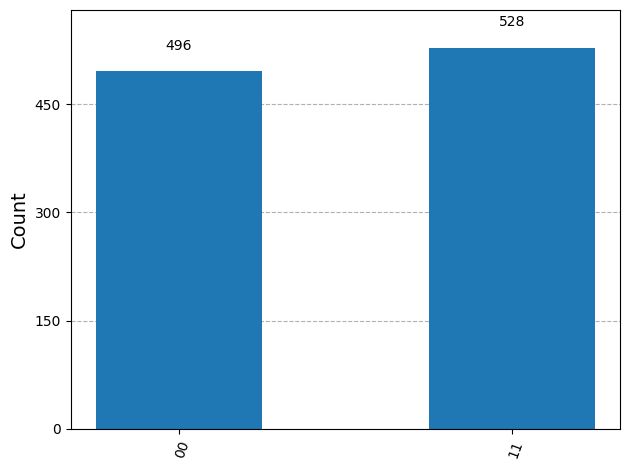

In [16]:
from qiskit import QuantumCircuit

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)

# Rotate into x-basis using a Hadamard gate, then make two measurements in succession
qc.h(0)
qc.measure(0, 0)
qc.barrier()
qc.measure(0, 1)

qc.draw("mpl")

job = sampler_sv.run([qc])
print(job.result()[0].data.c.get_counts())
plot_histogram(job.result()[0].data.c.get_counts())